In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Display all columns
pd.set_option("display.max_columns", None)

In [2]:
# Upload Housing.csv to Colab before running

df = pd.read_csv("/content/Housing.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (545, 13)


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [3]:
print("Dataset Information:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB
None

Missing Values:
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
m

In [4]:
# Remove duplicate rows
df = df.drop_duplicates()

# Check missing values
print(df.isnull().sum())

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


In [5]:
# Convert yes/no columns into numerical values

binary_columns = [
    'mainroad',
    'guestroom',
    'basement',
    'hotwaterheating',
    'airconditioning',
    'prefarea'
]

for col in binary_columns:
    df[col] = df[col].map({
        'yes': 1,
        'no': 0
    })

# Furnishing status encoding
encoder = LabelEncoder()
df['furnishingstatus'] = encoder.fit_transform(
    df['furnishingstatus']
)

df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,0


In [6]:
df.describe()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.858716,0.177982,0.350459,0.045872,0.315596,0.693578,0.234862,1.069725
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.348635,0.382849,0.477552,0.209399,0.465180,0.861586,0.424302,0.761373
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000,0.000000,1.000000,0.000000,1.000000,1.000000,0.000000,2.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.000000,1.000000,2.000000


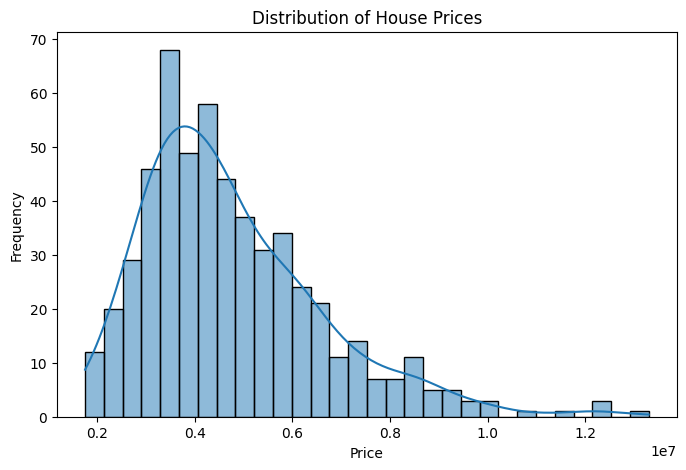

In [7]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['price'],
    kde=True,
    bins=30
)

plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.show()

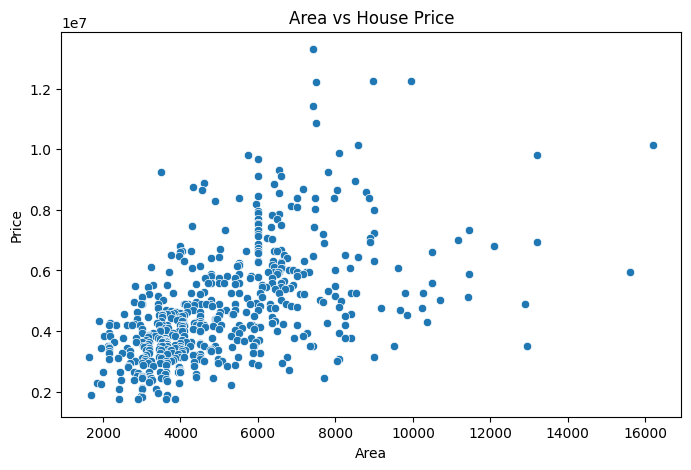

In [8]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=df['area'],
    y=df['price']
)

plt.title("Area vs House Price")
plt.xlabel("Area")
plt.ylabel("Price")

plt.show()

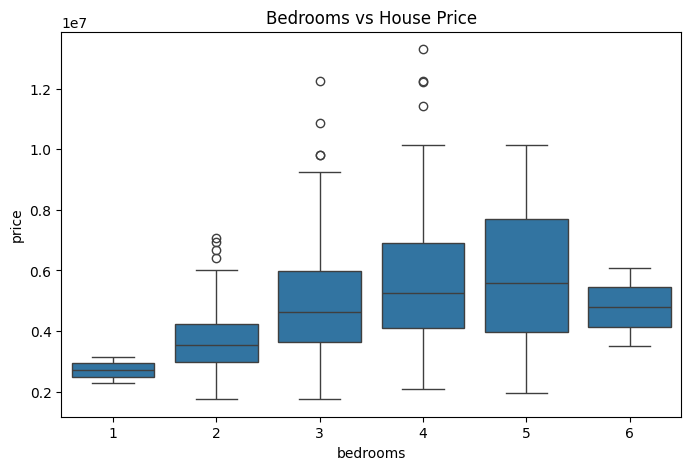

In [9]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df['bedrooms'],
    y=df['price']
)

plt.title("Bedrooms vs House Price")

plt.show()

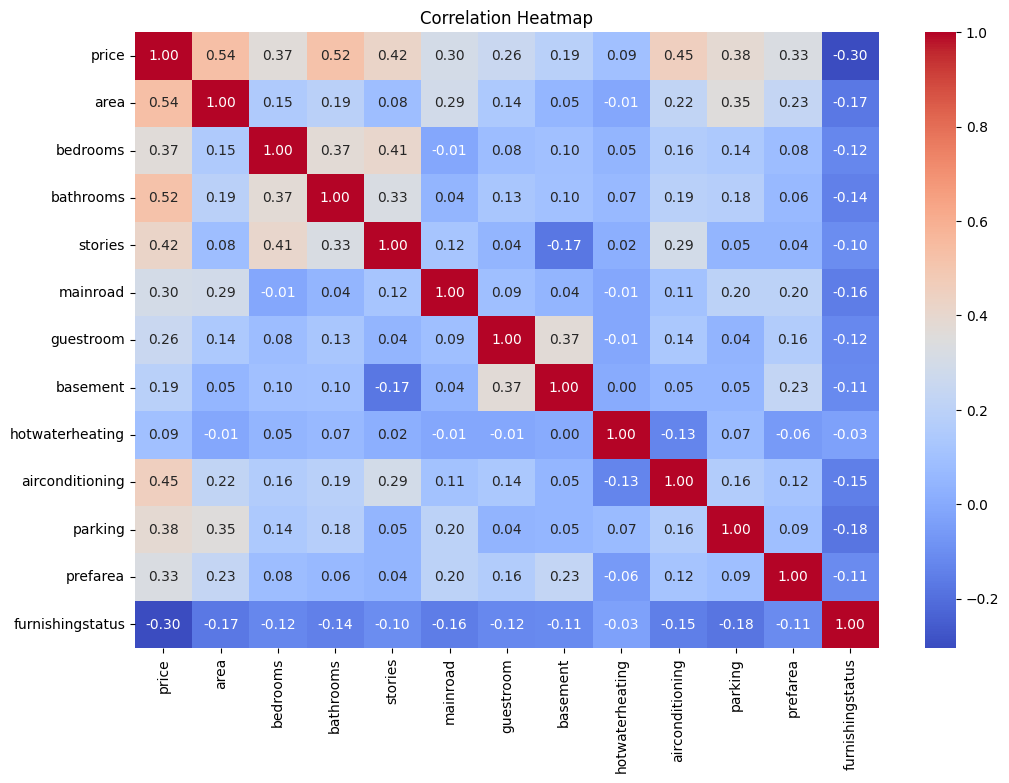

In [10]:
plt.figure(figsize=(12,8))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

In [11]:
X = df.drop("price", axis=1)
y = df["price"]

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (545, 12)
Target Shape: (545,)


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Samples:", X_train.shape[0])
print("Testing Samples:", X_test.shape[0])

Training Samples: 436
Testing Samples: 109


In [13]:
model = LinearRegression()

model.fit(
    X_train,
    y_train
)

print("Model training completed successfully.")

Model training completed successfully.


In [14]:
y_pred = model.predict(X_test)

prediction_df = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred
})

prediction_df.head()

,Actual Price,Predicted Price
0,4060000,5.203692e+06
1,6650000,7.257004e+06
2,3710000,3.062829e+06
3,6440000,4.559592e+06
4,2800000,3.332932e+06


In [15]:
mae = mean_absolute_error(
    y_test,
    y_pred
)

mse = mean_squared_error(
    y_test,
    y_pred
)

rmse = np.sqrt(mse)

r2 = r2_score(
    y_test,
    y_pred
)

print("Model Performance")
print("-" * 30)
print("Mean Absolute Error :", round(mae, 2))
print("Mean Squared Error  :", round(mse, 2))
print("Root Mean Squared Error :", round(rmse, 2))
print("R² Score :", round(r2, 4))

Model Performance
------------------------------
Mean Absolute Error : 979679.69
Mean Squared Error  : 1771751116594.04
Root Mean Squared Error : 1331071.42
R² Score : 0.6495


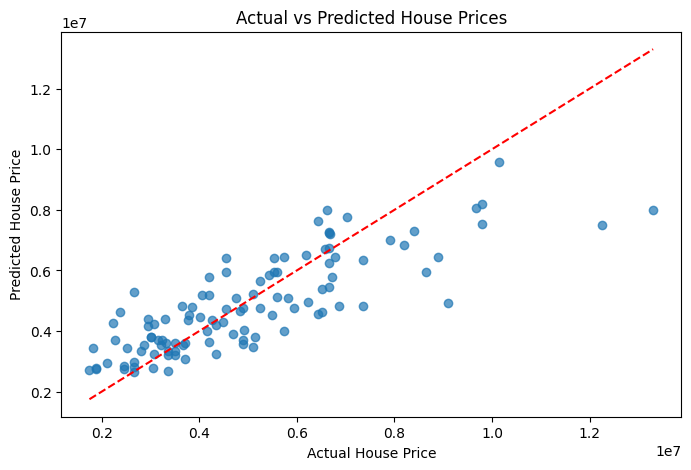

In [16]:
plt.figure(figsize=(8,5))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.7
)

plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")
plt.title("Actual vs Predicted House Prices")

# Perfect prediction line
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    color='red',
    linestyle='--'
)

plt.show()

In [17]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

importance = importance.sort_values(
    by="Coefficient",
    ascending=False
)

importance

,Feature,Coefficient
2,bathrooms,1.097117e+06
8,airconditioning,7.855506e+05
7,hotwaterheating,6.878813e+05
10,prefarea,6.299017e+05
3,stories,4.062232e+05
6,basement,3.931598e+05
4,mainroad,3.668242e+05
5,guestroom,2.331468e+05
9,parking,2.257565e+05
1,bedrooms,7.857449e+04


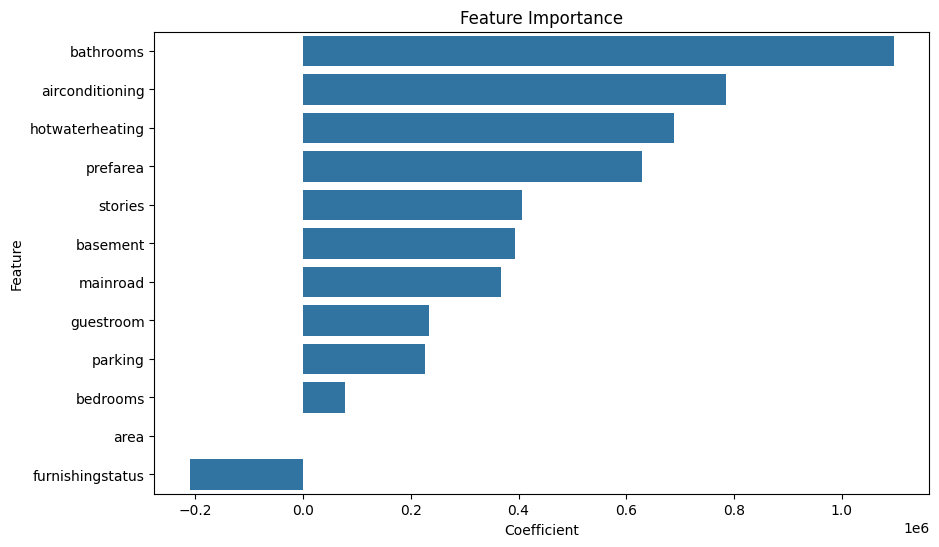

In [18]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance,
    x="Coefficient",
    y="Feature"
)

plt.title("Feature Importance")
plt.show()

In [19]:
sample_house = pd.DataFrame({
    "area": [7000],
    "bedrooms": [3],
    "bathrooms": [2],
    "stories": [2],
    "mainroad": [1],
    "guestroom": [0],
    "basement": [1],
    "hotwaterheating": [0],
    "airconditioning": [1],
    "parking": [2],
    "prefarea": [1],
    "furnishingstatus": [2]
})

predicted_price = model.predict(sample_house)

print(
    "Predicted House Price: ₹{:,.2f}".format(
        predicted_price[0]
    )
)

Predicted House Price: ₹7,392,583.81


In [20]:
import joblib

joblib.dump(
    model,
    "house_price_model.pkl"
)

print("Model saved successfully.")

Model saved successfully.
